# Project 2 | Simulation of Epidemics

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

## Part I

### Deterministic model

In [25]:
def sir_derivative(state, t, beta, gamma, N):
    S, I, R = state
    dS = -beta * S * I / N
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    
    return np.array([dS, dI, dR])

### Continuous-time stochastic model

In [26]:
def simulate_sir_continuous(N, beta, gamma, max_time=160):
    S, I, R = N - 1, 1, 0
    t = 0
    history = [(t, S, I, R)]

    while I > 0 and t < max_time:
        rate_infection = beta * S * I / N
        rate_recovery = gamma * I
        rate_total = rate_infection + rate_recovery

        t += np.random.exponential(1 / rate_total)

        if np.random.random() < rate_infection / rate_total:
            S -= 1
            I += 1
        else:
            I -= 1
            R += 1

        history.append((t, S, I, R))

    return np.array(history)

### Discrete-time (binomial) stochastic model

In [27]:
def simulate_sir_daily(N, beta, gamma, max_time=160):
    S, I, R = N - 1, 1, 0
    t = 0
    history = [(t, S, I, R)]

    while I > 0 and t < max_time:
        chance_of_infection = 1 - np.exp(-beta * I / N)
        new_infections = np.random.binomial(S, chance_of_infection)
        new_recoveries = np.random.binomial(I, gamma)

        S -= new_infections
        I += new_infections - new_recoveries
        R += new_recoveries
        t += 1

        history.append((t, S, I, R))

    return np.array(history)

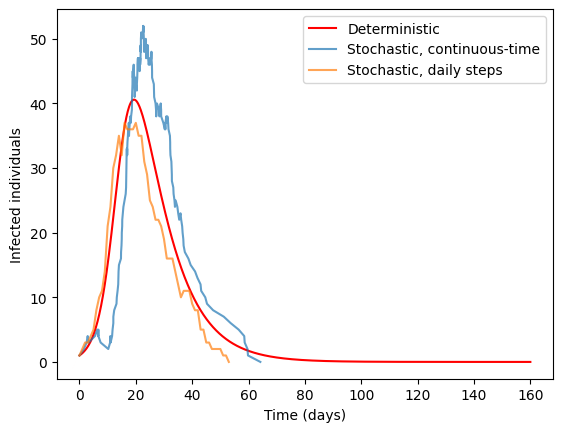

In [28]:
N = 100
beta = 0.4
gamma = 0.1
t_span = np.linspace(0, 160, 1000)
initial_state = [N - 1, 1, 0]
deterministic_solution = integrate.odeint(sir_derivative, initial_state, t_span, args=(beta, gamma, N))

np.random.seed(0)
history_continuous = simulate_sir_continuous(N, beta, gamma)
np.random.seed(500)
history_daily = simulate_sir_daily(N, beta, gamma)

plt.plot(t_span, deterministic_solution[:, 1], label="Deterministic", color="red")
plt.plot(history_continuous[:, 0], history_continuous[:, 2], label="Stochastic, continuous-time", alpha=0.7)
plt.plot(history_daily[:, 0], history_daily[:, 2], label="Stochastic, daily steps", alpha=0.7)
plt.xlabel("Time (days)")
plt.ylabel("Infected individuals")
plt.legend()
plt.show()

### Extinction probability

In [29]:
def extinction_probability(simulate_function, N, beta, gamma, n_simulations=1000):
    extinct_count = 0

    for _ in range(n_simulations):
        history = simulate_function(N, beta, gamma)
        peak_infected = history[:, 2].max()
        if peak_infected < 10:
            extinct_count += 1

    p = extinct_count / n_simulations
    confidence_interval = 1.96 * np.sqrt(p * (1 - p) / n_simulations)
    
    return p, confidence_interval

In [30]:
population_sizes = [100, 500, 1000, 10000]
beta = 0.3
gamma = 0.1

print("Continuous-time model, R0 =", beta / gamma)

for N in population_sizes:
    p, ci = extinction_probability(simulate_sir_continuous, N, beta, gamma)
    
    print(f"N={N}: p = {p:.4f} +/- {ci:.4f}")

Continuous-time model, R0 = 2.9999999999999996
N=100: p = 0.3320 +/- 0.0292
N=500: p = 0.3580 +/- 0.0297
N=1000: p = 0.3530 +/- 0.0296
N=10000: p = 0.3340 +/- 0.0292


In [31]:
print("Daily-step model, R0 =", beta / gamma)

for N in population_sizes:
    p, ci = extinction_probability(simulate_sir_daily, N, beta, gamma)
    
    print(f"N={N}: p = {p:.4f} +/- {ci:.4f}")

Daily-step model, R0 = 2.9999999999999996
N=100: p = 0.3010 +/- 0.0284
N=500: p = 0.2850 +/- 0.0280
N=1000: p = 0.3040 +/- 0.0285
N=10000: p = 0.3040 +/- 0.0285


### Stochastic versus deterministic dynamics

In [32]:
def plot_stochastic_vs_deterministic(simulate_function, color, beta, gamma):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, N in zip(axes, [100, 10000]):
        t_span = np.linspace(0, 160, 1000)
        initial_state = [N - 1, 1, 0]
        deterministic_solution = integrate.odeint(sir_derivative, initial_state, t_span, args=(beta, gamma, N))

        for _ in range(10):
            history = simulate_function(N, beta, gamma)
            ax.plot(history[:, 0], history[:, 2], alpha=0.5, color=color)

        ax.plot(t_span, deterministic_solution[:, 1], color="red", linewidth=2, label="Deterministic")
        ax.set_title(f"N = {N}")
        ax.set_xlabel("Time (days)")
        ax.set_ylabel("Infected individuals")
        ax.legend()

    plt.tight_layout()
    plt.show()

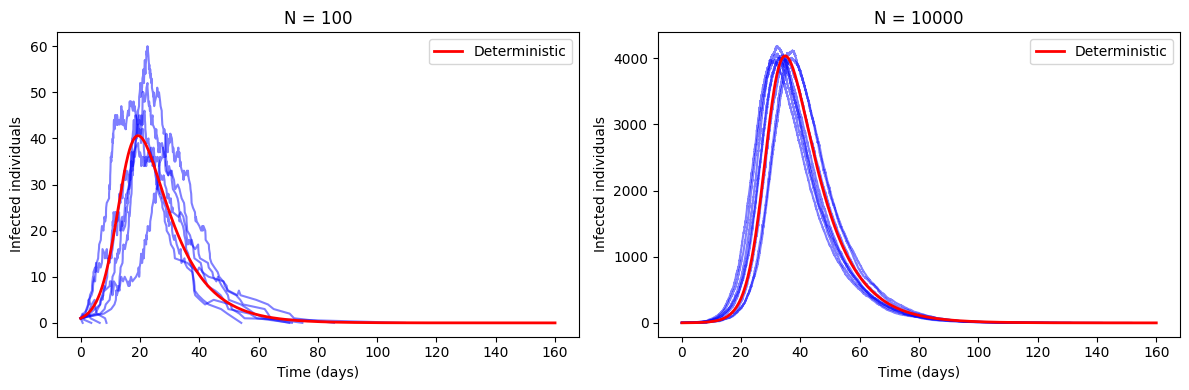

In [33]:
beta = 0.4
gamma = 0.1
plot_stochastic_vs_deterministic(simulate_sir_continuous, "blue", beta, gamma)

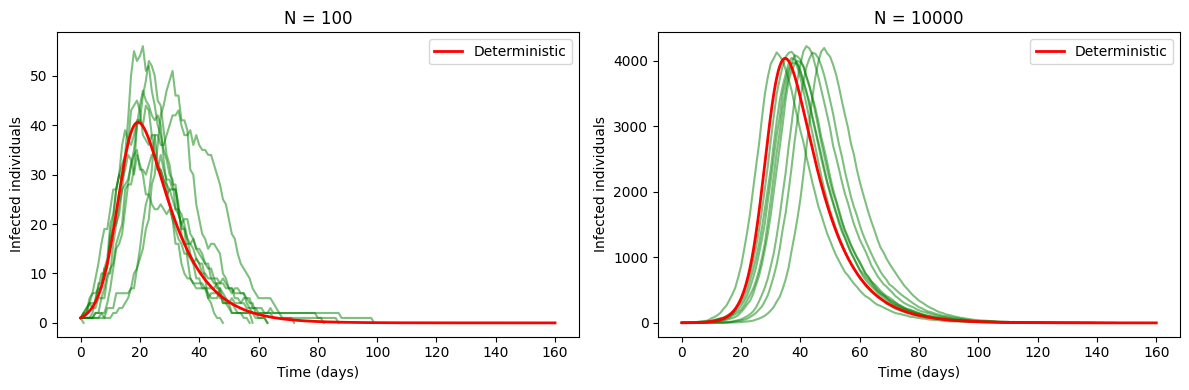

In [34]:
plot_stochastic_vs_deterministic(simulate_sir_daily, "green", beta, gamma)

## Part II

### Setting up the cities and travel network

In [35]:
city_names = ["Copenhagen", "Hillerod", "Odense", "Aarhus", "Aalborg"]
city_populations = np.array([660000, 37000, 188000, 290000, 122000])
number_of_cities = len(city_names)

travel_times_minutes = np.array([
    [0,   37,  118, 188, 269],
    [37,  0,   132, 195, 276],
    [118, 132, 0,   113, 177],
    [188, 195, 113, 0,   86],
    [269, 276, 177, 86,  0]
], dtype=float)

In [36]:
def build_travel_matrix(travel_times, alpha):
    n = len(travel_times)
    travel_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i != j:
                travel_matrix[i, j] = alpha / travel_times[i, j]
        travel_matrix[i, i] = 1 - travel_matrix[i].sum()
        
    return travel_matrix

In [37]:
mobility_level = 5.0
travel_matrix = build_travel_matrix(travel_times_minutes, mobility_level)

for i, name in enumerate(city_names):
    print(name, np.round(travel_matrix[i], 4))

Copenhagen [0.7773 0.1351 0.0424 0.0266 0.0186]
Hillerod [0.1351 0.7832 0.0379 0.0256 0.0181]
Odense [0.0424 0.0379 0.8473 0.0442 0.0282]
Aarhus [0.0266 0.0256 0.0442 0.8454 0.0581]
Aalborg [0.0186 0.0181 0.0282 0.0581 0.8769]


### Hospital capacity

In [38]:
beds_per_1000_people = 2.5
hospital_beds_per_city = (city_populations / 1000 * beds_per_1000_people).astype(int)

for name, beds in zip(city_names, hospital_beds_per_city):
    print(name, beds, "beds")

Copenhagen 1650 beds
Hillerod 92 beds
Odense 470 beds
Aarhus 725 beds
Aalborg 305 beds


### Disease dynamics with hospitals

In [39]:
infection_rate = 0.18
recovery_rate = 0.1
fraction_of_cases_that_are_severe = 0.1
death_rate_with_hospital_bed = 0.01
death_rate_without_hospital_bed = 0.05

In [40]:
def move_between_cities(people_per_city, travel_matrix):
    n = len(people_per_city)
    new_people_per_city = np.zeros(n, dtype=int)

    for i in range(n):
        new_people_per_city += np.random.multinomial(people_per_city[i], travel_matrix[i])
        
    return new_people_per_city

In [41]:
def simulate_one_day(susceptible, mild_cases, severe_cases, recovered, dead, travel_matrix, hospital_beds):

    susceptible = move_between_cities(susceptible, travel_matrix)
    mild_cases = move_between_cities(mild_cases, travel_matrix)
    severe_cases = move_between_cities(severe_cases, travel_matrix)
    recovered = move_between_cities(recovered, travel_matrix)

    population = susceptible + mild_cases + severe_cases + recovered
    infectious_people = mild_cases + severe_cases
    chance_of_infection = 1 - np.exp(-infection_rate * infectious_people / np.maximum(population, 1))

    new_cases = np.random.binomial(susceptible, chance_of_infection)
    new_severe_cases = np.random.binomial(new_cases, fraction_of_cases_that_are_severe)
    new_mild_cases = new_cases - new_severe_cases

    patients_with_bed = np.minimum(severe_cases, hospital_beds)
    patients_without_bed = severe_cases - patients_with_bed

    mild_recoveries = np.random.binomial(mild_cases, recovery_rate)
    hospital_recoveries = np.random.binomial(patients_with_bed, recovery_rate)
    hospital_deaths = np.random.binomial(patients_with_bed - hospital_recoveries, death_rate_with_hospital_bed)
    overflow_recoveries = np.random.binomial(patients_without_bed, recovery_rate)
    overflow_deaths = np.random.binomial(patients_without_bed - overflow_recoveries, death_rate_without_hospital_bed)

    susceptible = susceptible - new_cases
    mild_cases = mild_cases + new_mild_cases - mild_recoveries
    severe_cases = (severe_cases + new_severe_cases - hospital_recoveries - hospital_deaths - overflow_recoveries - overflow_deaths)
    recovered = recovered + mild_recoveries + hospital_recoveries + overflow_recoveries
    dead = dead + hospital_deaths + overflow_deaths

    return susceptible, mild_cases, severe_cases, recovered, dead

### Running the scenario: virus entering via Copenhagen

In [42]:
number_of_days = 250

susceptible = city_populations.copy()
mild_cases = np.zeros(number_of_cities, dtype=int)
severe_cases = np.zeros(number_of_cities, dtype=int)
recovered = np.zeros(number_of_cities, dtype=int)
dead = np.zeros(number_of_cities, dtype=int)

susceptible[0] -= 6
mild_cases[0] += 5
severe_cases[0] += 1

mild_cases_history = [mild_cases.copy()]
severe_cases_history = [severe_cases.copy()]
dead_history = [dead.copy()]

np.random.seed(2)
for day in range(number_of_days):
    susceptible, mild_cases, severe_cases, recovered, dead = simulate_one_day(
        susceptible, mild_cases, severe_cases, recovered, dead,
        travel_matrix, hospital_beds_per_city
    )
    mild_cases_history.append(mild_cases.copy())
    severe_cases_history.append(severe_cases.copy())
    dead_history.append(dead.copy())

mild_cases_history = np.array(mild_cases_history)
severe_cases_history = np.array(severe_cases_history)
dead_history = np.array(dead_history)
total_infectious_history = mild_cases_history + severe_cases_history

### How fast does the outbreak reach every city?

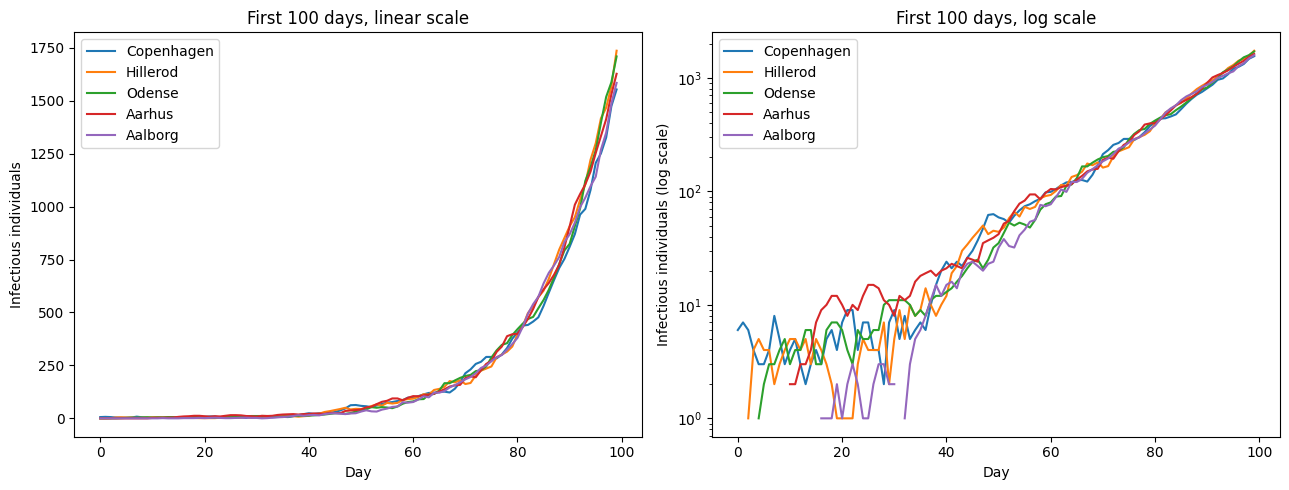

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(city_names):
    axes[0].plot(total_infectious_history[:100, i], label=name)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Infectious individuals")
axes[0].set_title("First 100 days, linear scale")
axes[0].legend()

for i, name in enumerate(city_names):
    values = total_infectious_history[:100, i].astype(float)
    values[values < 1] = np.nan
    axes[1].plot(values, label=name)
axes[1].set_yscale("log")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Infectious individuals (log scale)")
axes[1].set_title("First 100 days, log scale")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hospital capacity versus demand

In [44]:
print("City, population, hospital beds, peak severe cases")

for i, name in enumerate(city_names):
    peak_severe = severe_cases_history[:, i].max()
    
    print(f"{name}: population={city_populations[i]}, beds={hospital_beds_per_city[i]}, "
          f"peak severe cases={peak_severe}")

City, population, hospital beds, peak severe cases
Copenhagen: population=660000, beds=1650, peak severe cases=2372
Hillerod: population=37000, beds=92, peak severe cases=2359
Odense: population=188000, beds=470, peak severe cases=2283
Aarhus: population=290000, beds=725, peak severe cases=2405
Aalborg: population=122000, beds=305, peak severe cases=2288


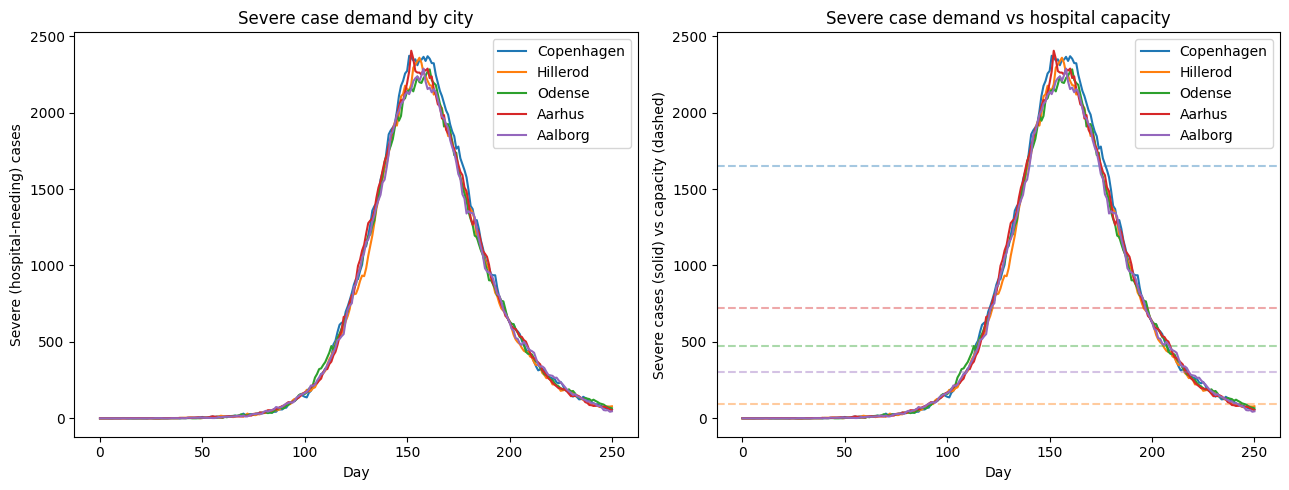

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(city_names): 
    axes[0].plot(severe_cases_history[:, i], label=name)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Severe (hospital-needing) cases")
axes[0].set_title("Severe case demand by city")
axes[0].legend()

for i, name in enumerate(city_names):
    axes[1].axhline(hospital_beds_per_city[i], color=f"C{i}", linestyle="--", alpha=0.4)
    axes[1].plot(severe_cases_history[:, i], color=f"C{i}", label=name)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Severe cases (solid) vs capacity (dashed)")
axes[1].set_title("Severe case demand vs hospital capacity")
axes[1].legend()

plt.tight_layout()
plt.show()

### Deaths per city

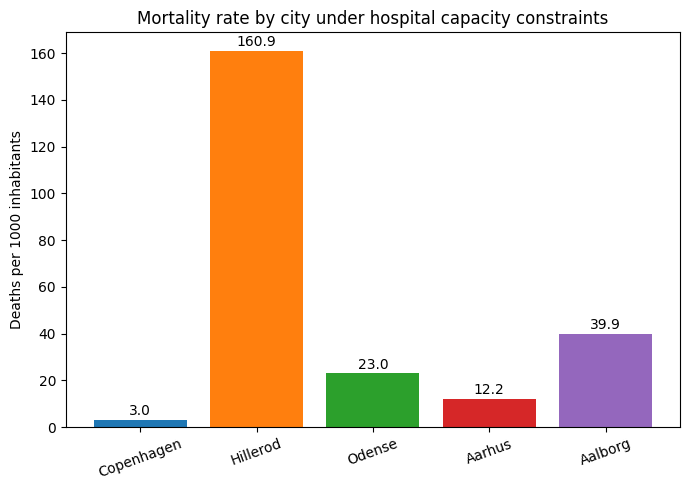

In [46]:
deaths_per_1000_people = dead_history[-1] / city_populations * 1000

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(city_names, deaths_per_1000_people, color=[f"C{i}" for i in range(number_of_cities)])
ax.set_ylabel("Deaths per 1000 inhabitants")
ax.set_title("Mortality rate by city under hospital capacity constraints")

for bar, value in zip(bars, deaths_per_1000_people):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.1f}", ha="center")
    
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()